In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

In [150]:
OCORRENCIAS = r'C:\analise de dados\03.BaseDPEvolucaoMensalCisp.csv'
DP = r'C:\analise de dados\08.DP.csv'

df_ocorrencias = pd.read_csv(
    OCORRENCIAS,
    sep=';',
    encoding= 'iso-8859-1'
)

df_DP = pd.read_csv(
    DP

)


In [151]:
df_merge = df_ocorrencias.merge(
    df_DP,
    how='left',
    right_on='codDP',
    left_on= 'cisp'
)

df_roubo_transeunte= df_merge[[
    'cisp', 'nome', 'roubo_transeunte', 'ano', 'mes', 'regiao', 'mes_ano'
]]

df_roubo_transeunte.info()
df_roubo_transeunte['nome'].isna() #verifica erros 
df_roubo_transeunte['nome'].isnull() #verifica vazio

df_roubo_transeunte = df_roubo_transeunte.fillna('DP não informada.') #'completa' os erros 


<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   cisp              34848 non-null  int64
 1   nome              34787 non-null  str  
 2   roubo_transeunte  34848 non-null  int64
 3   ano               34848 non-null  int64
 4   mes               34848 non-null  int64
 5   regiao            34848 non-null  str  
 6   mes_ano           34848 non-null  str  
dtypes: int64(4), str(3)
memory usage: 1.9 MB


In [152]:
df_roubo_transeunte_agg = (
    df_roubo_transeunte.groupby('nome')['roubo_transeunte']
    .sum().reset_index().sort_values(by='roubo_transeunte', ascending=False)
)
df_roubo_transeunte_agg

,nome,roubo_transeunte
51,059ª DP - Duque de Caxias,59518
56,064ª DP - São João de Meriti,43262
30,034ª DP - Bangu,42713
64,074ª DP - Alcântara,35892
25,029ª DP - Madureira,31430
...,...,...
117,142ª DP - Cambuci,13
129,156ª DP - Santa Maria Madalena,7
76,092ª DP - Rio das Flores,5
128,155ª DP - São Sebastião do Alto,4


In [153]:
roubo_transeunte_array = np.array(df_roubo_transeunte_agg['roubo_transeunte'])

media = np.mean(roubo_transeunte_array)
mediana = np.median(roubo_transeunte_array)
desvio = np.std(roubo_transeunte_array)
max = np.max(roubo_transeunte_array)
min = np.min(roubo_transeunte_array)
amplitude = (max - min)

delta_media_mediana = (media - mediana) # -> deslocamento

q1 = np.percentile(roubo_transeunte_array, 25)
q3 = np.percentile(roubo_transeunte_array, 75)
iqr = q3 - q1
#outliers - preparação
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr
cv = (desvio/media)*100

#formato de distribuição
assimetria = df_roubo_transeunte['roubo_transeunte'].skew()
curtose = df_roubo_transeunte['roubo_transeunte'].kurtosis()



In [154]:
print('Análise - ROUBO TRANSEUNTE')
print('-'*60)
print(f'Média: {media:.2f}')
print(f'Mediana: {mediana:.2f}')
print(f'Desvio padrão: {desvio:.2f}')
print(f'Q1: {q1:.2f}')
print(f'Q2/Mediana: {mediana:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Amplitude: {amplitude:.2f}')
print(f'Coeficiente de Variação(CV): {cv:.2f}')
print(f'Delta Média-Mediana: {delta_media_mediana:.2f}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')
print(f'Curtose: {curtose:.4f}')
print(f'Assimetria: {assimetria:.4f}')


Análise - ROUBO TRANSEUNTE
------------------------------------------------------------
Média: 8822.72
Mediana: 3799.50
Desvio padrão: 10972.33
Q1: 173.75
Q2/Mediana: 3799.50
Q3: 16100.50
IQR: 15926.75
Amplitude: 59515.00
Coeficiente de Variação(CV): 124.36
Delta Média-Mediana: 5023.22
Limite Inferior: -23716.375
Limite Superior: 39990.625
Curtose: 7.7882
Assimetria: 2.3693


In [155]:
df_roubo_transeunte_outliers_inf = (
    df_roubo_transeunte_agg[df_roubo_transeunte_agg['roubo_transeunte'] < limite_inferior]
)
df_roubo_transeunte_outliers_sup = (
    df_roubo_transeunte_agg[df_roubo_transeunte_agg['roubo_transeunte'] > limite_superior]
)


In [156]:
if len(df_roubo_transeunte_outliers_inf) <= 0:
    print('Não há outliers inferiores')
else:
        print(f'Há {len(df_roubo_transeunte_outliers_inf)} outliers inferiores. ')

if len(df_roubo_transeunte_outliers_sup) <= 0:
    print('Não há outliers superiores')
else:
        print(f'Há {len(df_roubo_transeunte_outliers_sup)} outliers superiores. ')

print(df_roubo_transeunte_outliers_sup)

Não há outliers inferiores
Há 3 outliers superiores. 
                            nome  roubo_transeunte
51     059ª DP - Duque de Caxias             59518
56  064ª DP - São João de Meriti             43262
30               034ª DP - Bangu             42713


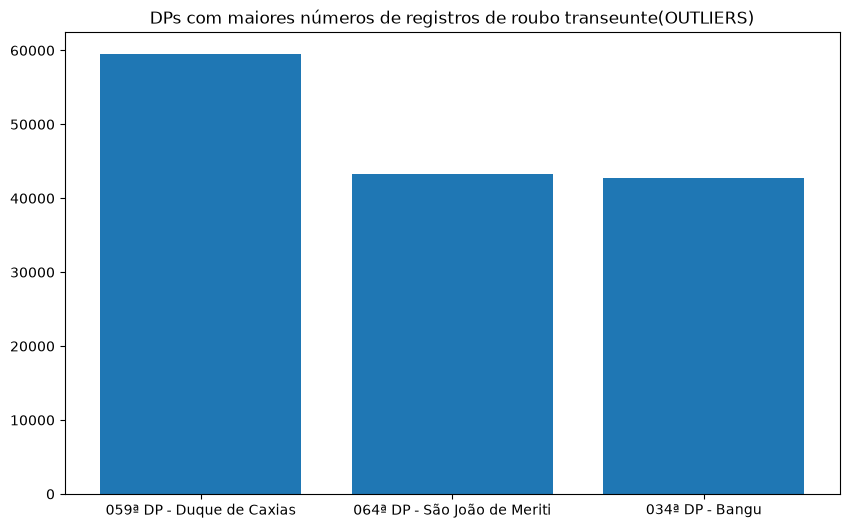

C:\Users\eduarda.castilho.SENACRJEDU\AppData\Local\Temp\ipykernel_24032\3446998169.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_roubo_transeunte_agg['roubo_transeunte'], showmeans=True, vert=False)


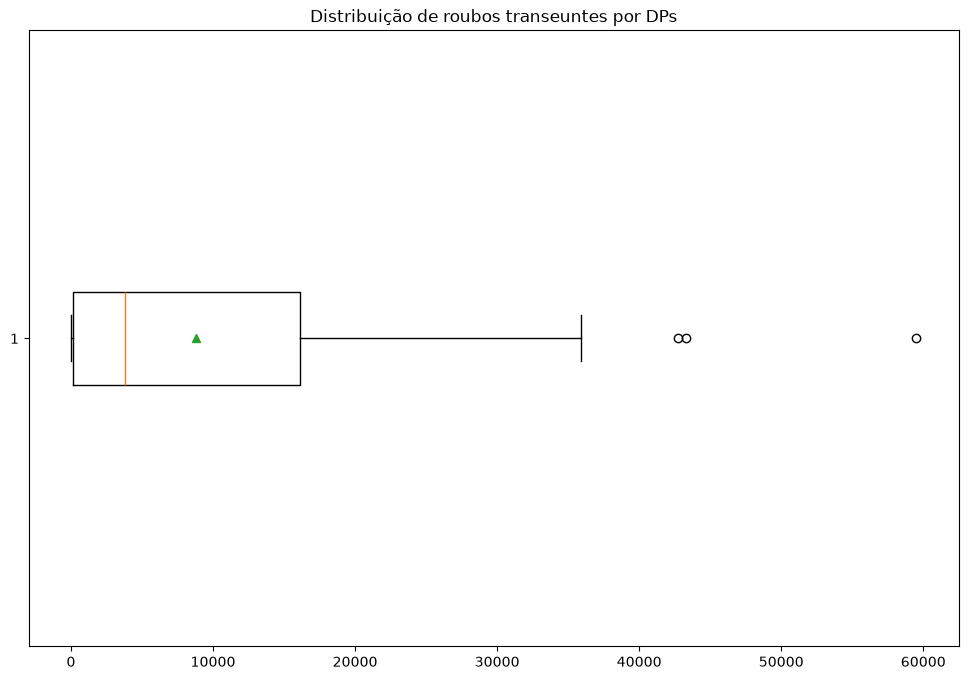

In [157]:

plt.figure(figsize=(10, 6))
plt.bar(df_roubo_transeunte_outliers_sup['nome'],
        df_roubo_transeunte_outliers_sup['roubo_transeunte'])
plt.title('DPs com maiores números de registros de roubo transeunte(OUTLIERS)')
plt.show()

plt.figure(figsize=(12, 8))
plt.boxplot(df_roubo_transeunte_agg['roubo_transeunte'], showmeans=True, vert=False)
plt.title('Distribuição de roubos transeuntes por DPs')
plt.show()

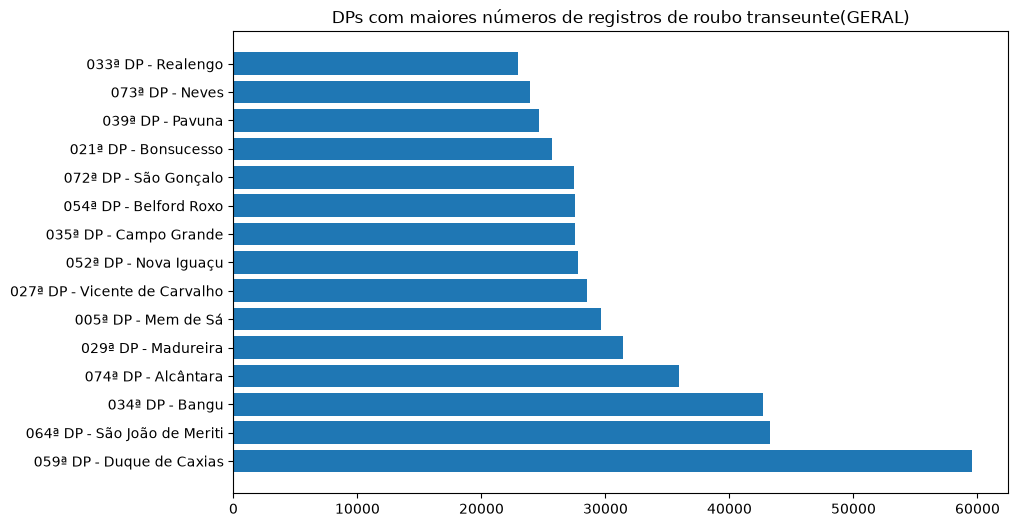

In [158]:

plt.figure(figsize=(10, 6))
# df_roubo_transeunte_agg = df_roubo_transeunte_agg
plt.barh(df_roubo_transeunte_agg['nome'].iloc[0:15],
        df_roubo_transeunte_agg['roubo_transeunte'].iloc[0:15])
plt.title('DPs com maiores números de registros de roubo transeunte(GERAL)')
plt.show()


In [159]:
df_merge = df_ocorrencias.merge(
    df_DP,
    how='left',
    right_on='codDP',
    left_on= 'cisp'
)

df_roubo_celular= df_merge[[
    'cisp', 'nome', 'roubo_celular', 'ano', 'mes', 'regiao', 'mes_ano'
]]

df_roubo_celular.info()
df_roubo_celular['nome'].isna() #verifica erros 
df_roubo_celular['nome'].isnull() #verifica vazio

df_roubo_celular = df_roubo_celular.fillna('DP não informada.') #'completa' os erros 


<class 'pandas.DataFrame'>
RangeIndex: 34848 entries, 0 to 34847
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   cisp           34848 non-null  int64
 1   nome           34787 non-null  str  
 2   roubo_celular  34848 non-null  int64
 3   ano            34848 non-null  int64
 4   mes            34848 non-null  int64
 5   regiao         34848 non-null  str  
 6   mes_ano        34848 non-null  str  
dtypes: int64(4), str(3)
memory usage: 1.9 MB


In [160]:
df_roubo_celular_agg = (
    df_roubo_celular.groupby('nome')['roubo_celular']
    .sum().reset_index().sort_values(by='roubo_celular', ascending=False)
)
df_roubo_celular_agg

,nome,roubo_celular
51,059ª DP - Duque de Caxias,12319
56,064ª DP - São João de Meriti,9414
30,034ª DP - Bangu,8771
25,029ª DP - Madureira,7814
29,033ª DP - Realengo,7175
...,...,...
93,111ª DP - Sumidouro,2
128,155ª DP - São Sebastião do Alto,1
125,152ª DP - Duas Barras,1
130,157ª DP - Trajano de Moraes,1


In [161]:
roubo_celular_array = np.array(df_roubo_celular_agg['roubo_celular'])

mediaC = np.mean(roubo_celular_array)
medianaC = np.median(roubo_celular_array)
desvioC = np.std(roubo_celular_array)
maxC = np.max(roubo_celular_array)
minC = np.min(roubo_celular_array)
amplitudeC = (maxC - minC)

delta_media_medianaC = (mediaC - medianaC)


q1C = np.percentile(roubo_celular_array, 25)
q3C = np.percentile(roubo_celular_array, 75)
iqrC = q3C - q1C
#outliers - preparação
limite_inferiorC = q1C - 1.5*iqrC
limite_superiorC = q3C + 1.5*iqrC
cvC = (desvioC/mediaC)*100

assimetriaC = df_roubo_celular['roubo_celular'].skew()
curtoseC = df_roubo_celular['roubo_celular'].kurtosis()

In [162]:
print('Análise - ROUBO CELULAR')
print('-'*60)
print(f'Média: {mediaC:.2f}')
print(f'Mediana: {medianaC:.2f}')
print(f'Desvio padrão: {desvioC:.2f}')
print(f'Desvio padrão: {desvio:.2f}')
print(f'Q1: {q1C:.2f}')
print(f'Q2/Mediana: {medianaC:.2f}')
print(f'Q3: {q3C:.2f}')
print(f'IQR: {iqrC:.2f}')
print(f'Máximo: {maxC}')
print(f'Amplitude: {amplitudeC:.2f}')
print(f'Coeficiente de Variação(CV): {cvC:.2f}')
print(f'Delta Média-Mediana: {delta_media_medianaC:.2f}')
print(f'Limite Inferior: {limite_inferiorC}')
print(f'Limite Superior: {limite_superiorC}')
print(f'Curtose: {curtoseC:.4f}')
print(f'Assimetria: {assimetriaC:.4f}')


Análise - ROUBO CELULAR
------------------------------------------------------------
Média: 2011.96
Mediana: 715.00
Desvio padrão: 2466.58
Desvio padrão: 10972.33
Q1: 43.25
Q2/Mediana: 715.00
Q3: 3746.50
IQR: 3703.25
Máximo: 12319
Amplitude: 12319.00
Coeficiente de Variação(CV): 122.60
Delta Média-Mediana: 1296.96
Limite Inferior: -5511.625
Limite Superior: 9301.375
Curtose: 18.8006
Assimetria: 3.3719


In [163]:
df_roubo_celular_outliers_inf = (
    df_roubo_celular_agg[df_roubo_celular_agg['roubo_celular'] < limite_inferiorC]
)
df_roubo_celular_outliers_sup = (
    df_roubo_celular_agg[df_roubo_celular_agg['roubo_celular'] > limite_superiorC]
)

if len(df_roubo_celular_outliers_inf) <= 0:
    print('Não há outliers inferiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_inf)} outliers inferiores. ')

if len(df_roubo_celular_outliers_sup) <= 0:
    print('Não há outliers superiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_sup)} outliers superiores. ')

print(df_roubo_celular_outliers_sup)

Não há outliers inferiores
Há 2 outliers superiores. 
                            nome  roubo_celular
51     059ª DP - Duque de Caxias          12319
56  064ª DP - São João de Meriti           9414


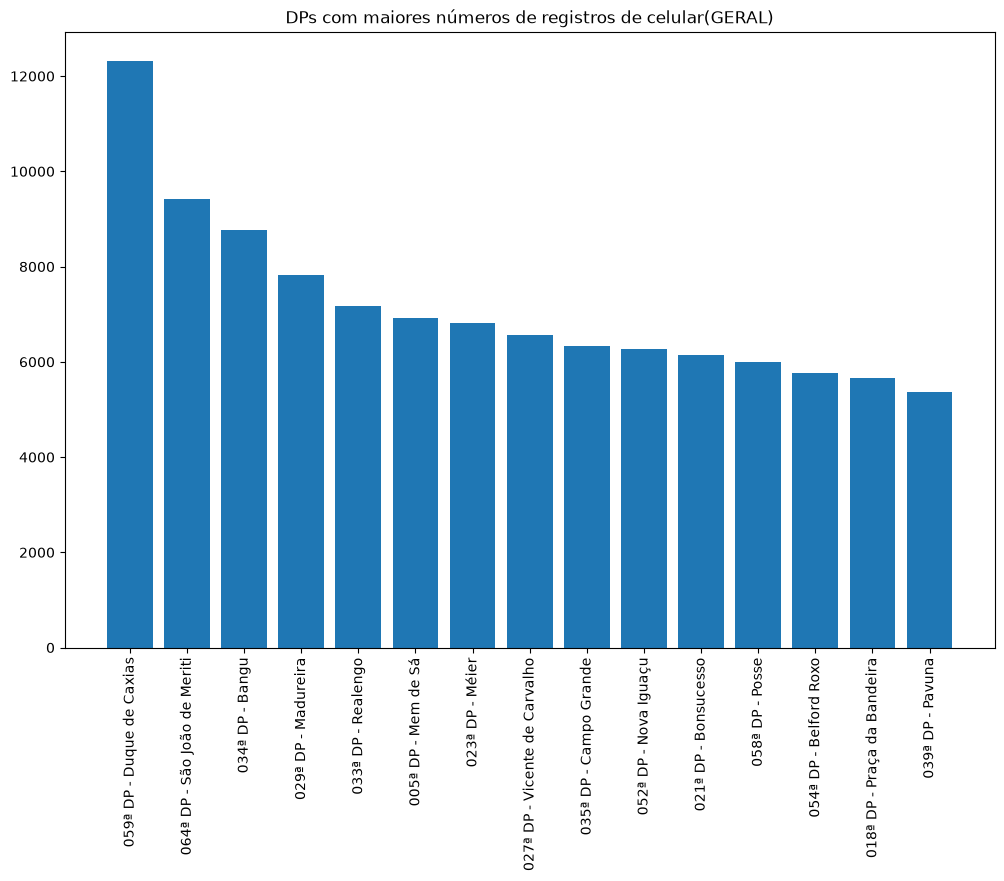

C:\Users\eduarda.castilho.SENACRJEDU\AppData\Local\Temp\ipykernel_24032\1657433508.py:10: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_roubo_celular_agg['roubo_celular'], showmeans=True, vert=False)


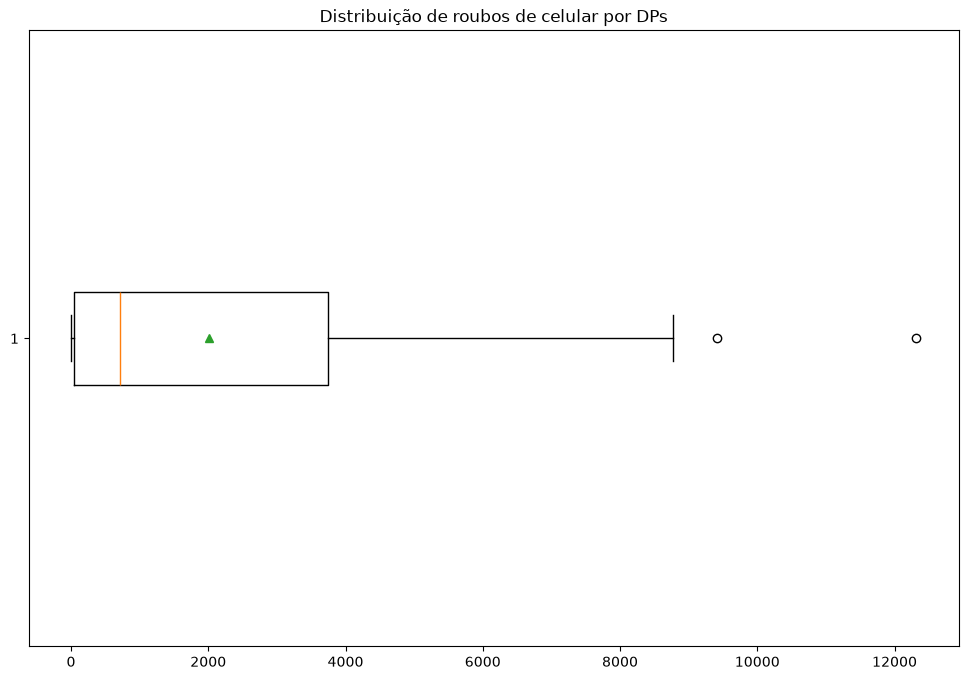

In [164]:
plt.figure(figsize=(12, 8))
df_roubo_celular_agg2 = df_roubo_celular_agg.iloc[0:15]
plt.xticks(rotation=90)
plt.bar(df_roubo_celular_agg2['nome'],
        df_roubo_celular_agg2['roubo_celular'])
plt.title('DPs com maiores números de registros de celular(GERAL)')
plt.show()

plt.figure(figsize=(12, 8))
plt.boxplot(df_roubo_celular_agg['roubo_celular'], showmeans=True, vert=False)
plt.title('Distribuição de roubos de celular por DPs')
plt.show()

In [165]:

df_roubo_celular_outlier_mes = (
    df_roubo_celular.groupby('mes_ano')['roubo_celular']
    .sum().reset_index().sort_values(by='roubo_celular', ascending=False)
)
df_roubo_celular_outlier_mes.sum()

mes_ano          2019m032017m052017m042018m102017m072019m052019...
roubo_celular                                               277651
dtype: object

In [166]:

maior_DP_outlier = df_roubo_celular[
    (df_roubo_celular['nome'] == '059ª DP - Duque de Caxias') 
]


ranking_meses_caxias = (
    maior_DP_outlier.groupby('mes_ano')['roubo_celular']
    .sum()
    .reset_index()
    .sort_values(by='roubo_celular', ascending=False)
)

ranking_meses_total = (
    df_roubo_celular.groupby('mes_ano')['roubo_celular']
    .sum()
    .reset_index()
    .sort_values(by='roubo_celular', ascending=False)
)



total_meses = len(ranking_meses_total)
total_de_meses_outliers = len(ranking_meses_caxias)
print(f'Detalhamento TOTAL : {ranking_meses_total}')
print(f'Total de meses: {total_meses}')
print(f'A 059ª DP - Duque de Caxias é outlier por {total_de_meses_outliers} meses.')
print(f"\n Detalhamento dos meses CAXIAS:\n {ranking_meses_caxias}")



Detalhamento TOTAL :      mes_ano  roubo_celular
194  2019m03           2626
172  2017m05           2548
171  2017m04           2520
189  2018m10           2477
174  2017m07           2468
..       ...            ...
120  2013m01            348
116  2012m09            337
118  2012m11            312
107  2011m12            303
119  2012m12            301

[259 rows x 2 columns]
Total de meses: 259
A 059ª DP - Duque de Caxias é outlier por 259 meses.

 Detalhamento dos meses CAXIAS:
      mes_ano  roubo_celular
189  2018m10            205
188  2018m09            172
190  2018m11            164
191  2018m12            157
185  2018m06            154
..       ...            ...
134  2014m03             11
123  2013m04             11
132  2014m01              7
169  2017m02              7
133  2014m02              3

[259 rows x 2 columns]


In [167]:
df_roubo_transeunte= df_merge[[
    'cisp', 'nome', 'roubo_transeunte', 'ano'
]]


correlacao = (
    df_roubo_transeunte_agg['roubo_transeunte'].corr(df_roubo_celular_agg['roubo_celular'])
)

print(f'Correlação: {correlacao:.4f}')

Correlação: 0.9718


4. VISUALIZAÇÃO DE DADOS


C:\Users\eduarda.castilho.SENACRJEDU\AppData\Local\Temp\ipykernel_24032\943598535.py:12: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot([df_roubo_celular_agg['roubo_celular'],df_roubo_transeunte_agg['roubo_transeunte']],
C:\Users\eduarda.castilho.SENACRJEDU\AppData\Local\Temp\ipykernel_24032\943598535.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


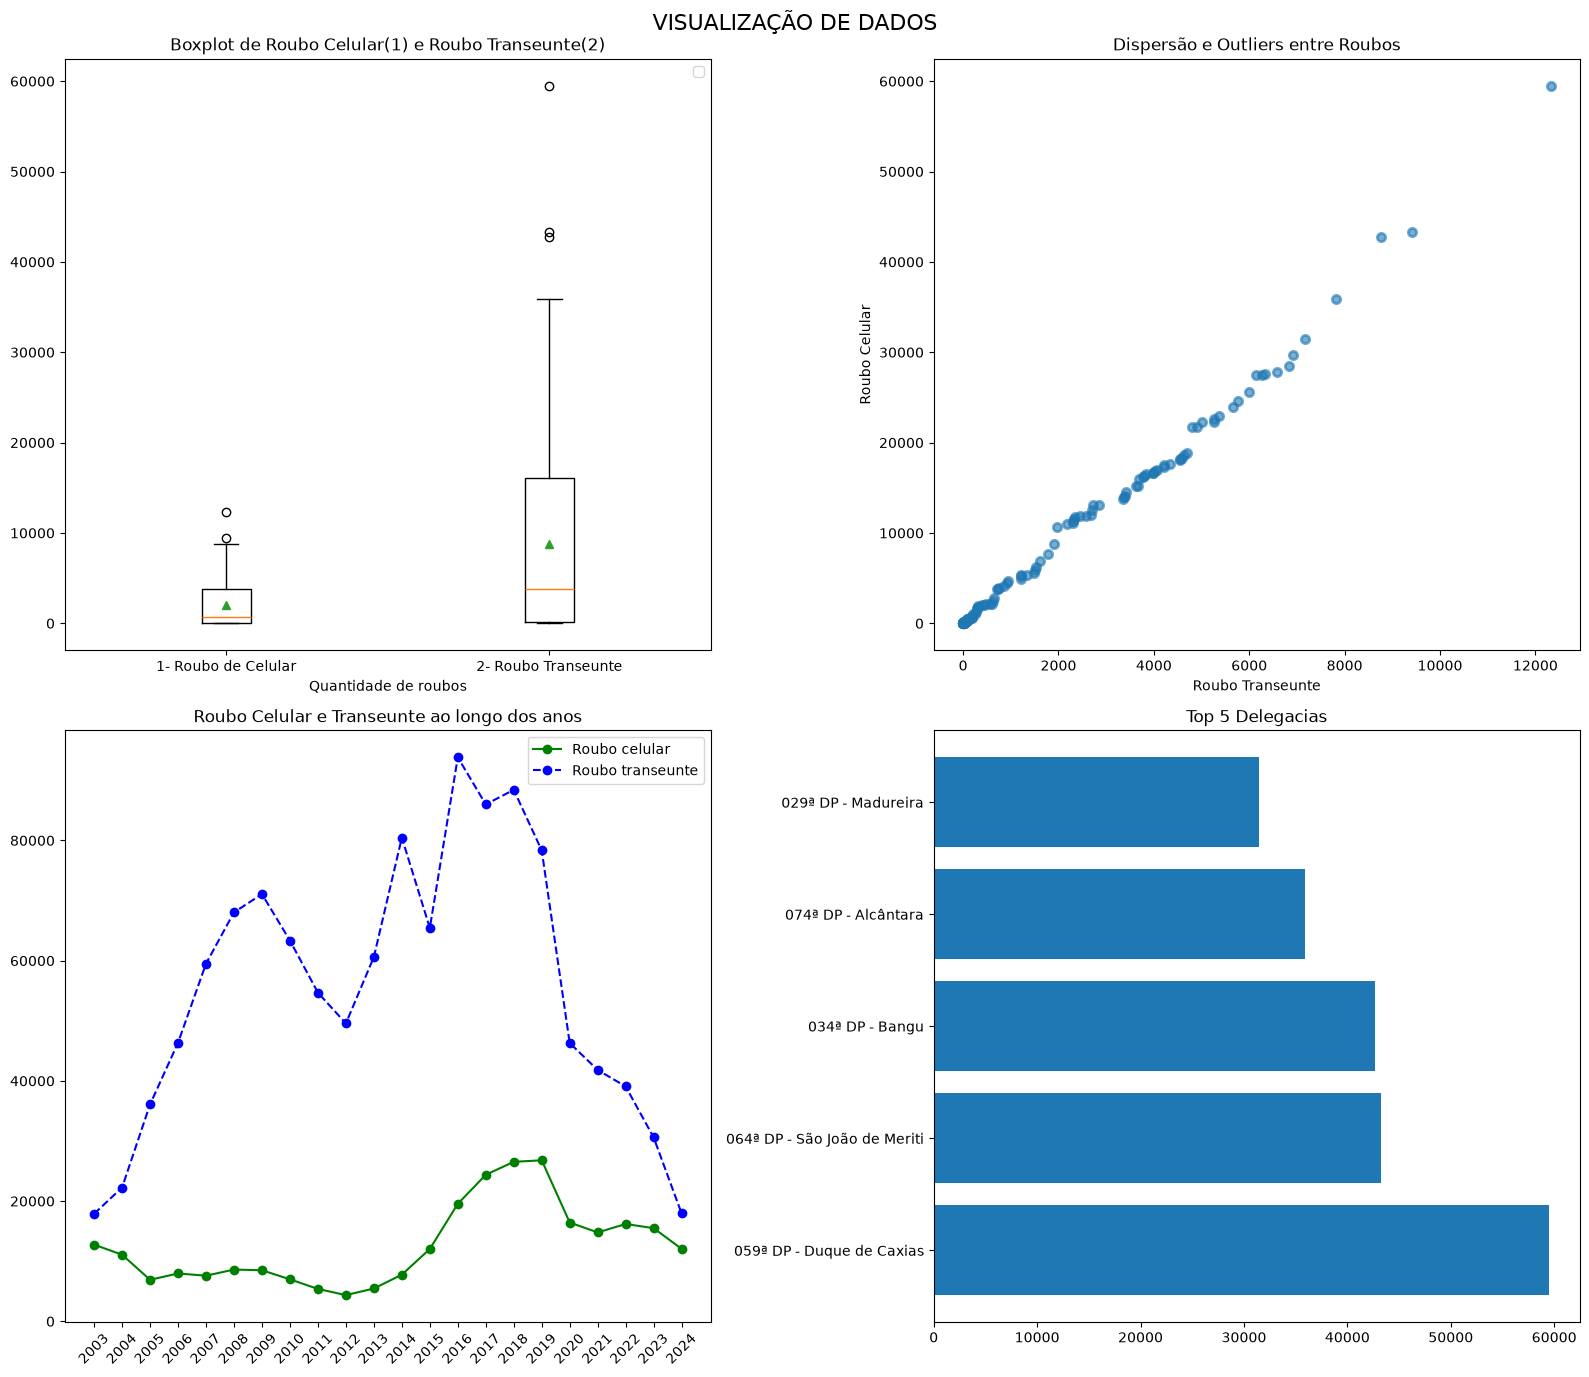

In [208]:


# "painel" de graficos 
# 1. criar uma area para os graficos
plt.subplots(2, 2, figsize=(16, 14))
# (numLinhas, numColunas, tamanhoImagem)
plt.suptitle('VISUALIZAÇÃO DE DADOS', fontsize=16)
#titulo dos plots (imagem)
# subplot -> (x, y, z) -> x e y repetem valor dos subplots
# z -> posição do grafico no subplot 

# PRIMEIRO GRÁFICO: plotar roubo_transeunte e roubo_veiculo 
plt.subplot(2, 2, 1) #primeiro grafico
plt.boxplot([df_roubo_celular_agg['roubo_celular'],df_roubo_transeunte_agg['roubo_transeunte']],
            showfliers=True,
            showmeans=True,
            vert=True,
            tick_labels= ['1- Roubo de Celular','2- Roubo Transeunte']
            )
plt.xlabel('Quantidade de roubos')
plt.legend()
plt.title('Boxplot de Roubo Celular(1) e Roubo Transeunte(2)')
# SEGUNDO GRAFICO: SCATTER PLOT
plt.subplot(2, 2, 2)
plt.scatter(df_roubo_celular_agg['roubo_celular'], df_roubo_transeunte_agg['roubo_transeunte'],alpha=0.6,linestyle='-', linewidth=2)
plt.xlabel('Roubo Transeunte')
plt.ylabel('Roubo Celular')
plt.title('Dispersão e Outliers entre Roubos')

# TERCEIRO GRÁFICO: TENDENCIA TEMPORAL
plt.subplot(2, 2, 3)
df_roubo_celular_ano = (
    df_roubo_celular.groupby('ano')['roubo_celular'].sum().reset_index().sort_values(by='ano', ascending = True)
)
df_roubo_transeunte_ano = (
     df_roubo_transeunte.groupby('ano')['roubo_transeunte'].sum().reset_index().sort_values(by='ano', ascending = True)
)
plt.plot(df_roubo_celular_ano['ano'].astype(str), df_roubo_celular_ano['roubo_celular'],
         marker='o', color='green', linestyle='-', label='Roubo celular')
plt.plot(df_roubo_transeunte_ano['ano'].astype(str), df_roubo_transeunte_ano['roubo_transeunte'],
         marker='o', color='blue', linestyle='--',label='Roubo transeunte')
plt.title('Roubo Celular e Transeunte ao longo dos anos')
plt.legend()

plt.xticks(rotation=45)


plt.subplot(2, 2, 4)
plt.title('Top 5 Delegacias')
plt.barh(df_roubo_transeunte_agg['nome'].iloc[0:5], df_roubo_transeunte_agg['roubo_transeunte'].iloc[0:5])
#plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


